<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_5_(Exercise_5_2)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Imports and Data

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='./data', train=True,
                             download=True, transform=transform)
train_data = Subset(train_data, range(10000))
train_loader = DataLoader(train_data, batch_size=128,
                          shuffle=True, num_workers=0)

# Full test set (not subsetted) so we can find a real '7' easily
test_data_full = datasets.MNIST(root='./data', train=False,
                                 download=True, transform=transform)

Using: cpu


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.55MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.24MB/s]


In [2]:
# Noise Schedule

T = 1000

def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas     = torch.linspace(beta_start, beta_end, T)
    alphas    = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    return betas, alpha_bar

betas, alpha_bar = linear_schedule(T)
betas            = betas.to(device)
alpha_bar        = alpha_bar.to(device)

In [3]:
# Class-Conditional U-Net

class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device) *
            (np.log(10000) / (half - 1)))
        angles = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


class ClassConditionalUNet(nn.Module):
    def __init__(self, t_emb_dim=128, n_classes=10):
        super().__init__()
        self.t_emb     = SinusoidalEmbedding(t_emb_dim)
        self.t_mlp     = nn.Sequential(
            nn.Linear(t_emb_dim, t_emb_dim), nn.SiLU())
        self.class_emb = nn.Linear(n_classes, t_emb_dim)

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.GroupNorm(8, 32), nn.SiLU())
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, stride=2),
            nn.GroupNorm(8, 64), nn.SiLU())

        self.t_proj1 = nn.Linear(t_emb_dim, 32 * 2)
        self.t_proj2 = nn.Linear(t_emb_dim, 64 * 2)
        self.t_proj3 = nn.Linear(t_emb_dim, 64 * 2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GroupNorm(8, 64), nn.SiLU())

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(64 + 64, 32, 2, stride=2),
            nn.GroupNorm(8, 32), nn.SiLU())
        self.dec1 = nn.Sequential(
            nn.Conv2d(32 + 32, 1, 3, padding=1))

    def apply_adagn(self, h, t_emb, proj):
        out          = proj(t_emb)
        scale, shift = out.chunk(2, dim=-1)
        scale        = scale.unsqueeze(-1).unsqueeze(-1)
        shift        = shift.unsqueeze(-1).unsqueeze(-1)
        return scale * h + shift

    def forward(self, x, t, c):
        """
        x: (B, 1, 28, 28)
        t: (B,) timestep indices
        c: (B, 10) one-hot class label
        """
        t_emb = self.t_mlp(self.t_emb(t))
        t_emb = t_emb + self.class_emb(c)

        h1 = self.enc1(x)
        h1 = self.apply_adagn(h1, t_emb, self.t_proj1)

        h2 = self.enc2(h1)
        h2 = self.apply_adagn(h2, t_emb, self.t_proj2)

        h  = self.bottleneck(h2)
        h  = self.apply_adagn(h, t_emb, self.t_proj3)

        h  = self.dec2(torch.cat([h, h2], dim=1))
        h  = self.dec1(torch.cat([h, h1], dim=1))
        return h

In [4]:
# Train

def train_model(epochs=10):
    model     = ClassConditionalUNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        epoch_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            B     = imgs.shape[0]
            t_idx = torch.randint(0, T, (B,), device=device)

            ab  = alpha_bar[t_idx].view(-1, 1, 1, 1)
            eps = torch.randn_like(imgs)
            x_t = (ab ** 0.5) * imgs + ((1 - ab) ** 0.5) * eps

            c_onehot = torch.zeros(B, 10, device=device)
            c_onehot.scatter_(1, labels.unsqueeze(1), 1.0)

            pred = model(x_t, t_idx, c_onehot)
            loss = criterion(pred, eps)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} "
              f"— Loss: {epoch_loss/len(train_loader):.6f}")

    return model


print("Training class-conditional model...")
model = train_model(epochs=10)
print("Done.")

Training class-conditional model...
Epoch 1/10 — Loss: 0.231442
Epoch 2/10 — Loss: 0.067862
Epoch 3/10 — Loss: 0.054892
Epoch 4/10 — Loss: 0.045539
Epoch 5/10 — Loss: 0.042484
Epoch 6/10 — Loss: 0.040264
Epoch 7/10 — Loss: 0.038830
Epoch 8/10 — Loss: 0.038146
Epoch 9/10 — Loss: 0.036506
Epoch 10/10 — Loss: 0.035822
Done.


In [5]:
# DDIM Invert and Sample (Conditioned)

def get_respaced_timesteps(num_steps, T=1000):
    idx = np.linspace(0, T - 1, num_steps)
    idx = np.unique(np.round(idx).astype(int))
    return idx


def ddim_invert(model, x0, c, alpha_bar, timesteps):
    model.eval()
    x = x0.clone()
    ab_list = [torch.tensor(1.0, device=x0.device)] + \
              [alpha_bar[t] for t in timesteps]

    with torch.no_grad():
        for i, t_cur in enumerate(timesteps):
            ab_now  = ab_list[i]
            ab_next = ab_list[i + 1]

            t_tensor = torch.full((x.shape[0],), int(t_cur),
                                  dtype=torch.long, device=x.device)
            eps_pred = model(x, t_tensor, c)

            x0_pred = (x - (1 - ab_now).sqrt() * eps_pred) / ab_now.sqrt()
            x = ab_next.sqrt() * x0_pred + (1 - ab_next).sqrt() * eps_pred

    return x


def ddim_sample(model, xT, c, alpha_bar, timesteps):
    model.eval()
    x = xT.clone()
    ab_list = [torch.tensor(1.0, device=xT.device)] + \
              [alpha_bar[t] for t in timesteps]

    with torch.no_grad():
        for i in range(len(timesteps), 0, -1):
            t_cur   = timesteps[i - 1]
            ab_now  = ab_list[i]
            ab_prev = ab_list[i - 1]

            t_tensor = torch.full((x.shape[0],), int(t_cur),
                                  dtype=torch.long, device=x.device)
            eps_pred = model(x, t_tensor, c)

            x0_pred = (x - (1 - ab_now).sqrt() * eps_pred) / ab_now.sqrt()
            x = ab_prev.sqrt() * x0_pred + (1 - ab_prev).sqrt() * eps_pred

    return x

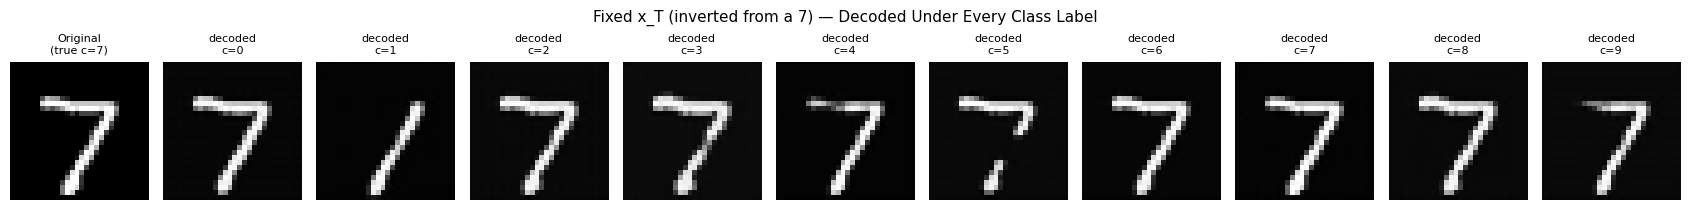

In [6]:
# The Actual Experiment

# Find a real '7' in the full test set
seven_idx = (test_data_full.targets == 7).nonzero(as_tuple=True)[0][0].item()
x0_seven, true_label = test_data_full[seven_idx]
x0_seven = x0_seven.unsqueeze(0).to(device)   # (1, 1, 28, 28)

n_steps   = 100   # near-perfect inversion per 5.1 results
timesteps = get_respaced_timesteps(n_steps, T)

# Invert using the TRUE label (c=7) — this is the honest noise code
c_seven = torch.zeros(1, 10, device=device)
c_seven[0, 7] = 1.0

x_T = ddim_invert(model, x0_seven, c_seven, alpha_bar, timesteps)

# Decode the SAME x_T under every possible class label
decoded = []
for class_label in range(10):
    c_test = torch.zeros(1, 10, device=device)
    c_test[0, class_label] = 1.0
    x0_decoded = ddim_sample(model, x_T, c_test, alpha_bar, timesteps)
    decoded.append(x0_decoded[0, 0].cpu().numpy())

fig, axes = plt.subplots(1, 11, figsize=(17, 2.2))

axes[0].imshow(x0_seven[0, 0].cpu().numpy(), cmap='gray')
axes[0].set_title("Original\n(true c=7)", fontsize=8)
axes[0].axis('off')

for i, img in enumerate(decoded):
    axes[i + 1].imshow(img, cmap='gray')
    axes[i + 1].set_title(f"decoded\nc={i}", fontsize=8)
    axes[i + 1].axis('off')

plt.suptitle("Fixed x_T (inverted from a 7) — Decoded Under Every Class Label",
             fontsize=11)
plt.tight_layout()
plt.savefig('decomposition_5_2.png', dpi=150)
plt.show()

# Interpretation And Observation

#### Fixing x_T from a real inverted 7 and decoding it under nine mismatched class labels produced almost no change in digit identity for eight of the nine labels, with the sole clear exception of c=1, where the output lost its horizontal top stroke and became a thin diagonal line resembling a 1, plus a partial shift for c=5. This departs from the naive expectation that class conditioning would cleanly override digit identity, and the reason traces back to the training distribution: every training pair had a label matching its true image content, so the network was never required to learn how to prioritise a label over what x_t already shows, and per Exercise 3.2's finding that x_t ≈ x_0 at low t, the digit's identity is legible from the input well before the label could meaningfully redirect it. The two labels that did produce visible change, 1 and 5, both require only a small structural edit from a 7's stroke pattern, suggesting the conditioning signal carries just enough strength to nudge a local change but not enough to force a complete structural rewrite against the trajectory x_T already set. This is precisely why LDAE does not use naive one-hot conditioning for its semantic decomposition: it instead trains a dedicated semantic encoder alongside a gradient estimator whose explicit purpose is to compute the correction needed to steer the denoising trajectory toward a target semantic embedding, overriding x_T's influence where necessary rather than competing weakly against it through the same pathway used for timestep conditioning.